# Detección de anomalías en transacciones — exploración del modelo

**Objetivo:** explorar `IsolationForest` de scikit-learn para detectar transacciones anómalas, como base para el build `03-anomaly-detection-transactions-python` del portafolio de AWS.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (ULB) — 284,807 transacciones, 492 marcadas como fraude (`Class=1`), el resto normales.

**Nota:** el modelo es **no supervisado** — nunca se le pasa `Class` durante el entrenamiento. La columna `Class` solo se usa después, para validar qué tan bien el modelo detecta los fraudes reales sin haberlos visto.

In [26]:
import pandas as pd

In [27]:
df = pd.read_csv('./../data/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [28]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

## Sobre las columnas del dataset

- **`V1`–`V28`**: 28 features numéricas resultado de un PCA aplicado por los autores del dataset sobre los datos originales (confidenciales). No son interpretables individualmente, pero preservan la señal necesaria para distinguir fraude de no-fraude.
- **`Time`**: segundos desde la primera transacción del dataset. No se usa como feature — no aporta señal real de anomalía.
- **`Amount`**: monto real de la transacción, sin transformar por el PCA.
- **`Class`**: etiqueta real (0 = normal, 1 = fraude). No se le pasa al modelo — solo se usa para *validar* después.

## Intuición de Isolation Forest

El modelo arma muchos árboles que parten los datos con cortes al azar (columna al azar + valor umbral al azar). Un punto **anómalo** queda aislado rápido (pocos cortes) porque está lejos del resto — casi cualquier corte al azar lo separa. Un punto **normal** está rodeado de puntos parecidos, así que hacen falta muchos más cortes para aislarlo solo a él.

El promedio de cortes necesarios para aislar cada fila (a través de todos los árboles) se traduce en un **score de anomalía** vía `decision_function()` (score bajo = más anómalo). El parámetro `contamination` le dice al modelo qué % de los datos esperamos que sea anómalo, y define el umbral que separa `-1` (anomalía) de `1` (normal) en `predict()`.

## Contaminacion de 1%

Primer intento: le decimos al modelo que esperamos que ~1% de las transacciones sean anómalas (`contamination=0.01`), sin transformar ninguna columna.

In [29]:
from sklearn.ensemble import IsolationForest

# 1. Seleccionas las columnas que va a "ver" el modelo
X = df[["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28", "Amount"]]  # sin Time, sin Class

# 2. Creas el modelo, diciéndole qué % esperas que sea anómalo
modelo = IsolationForest(contamination=0.01, random_state=42)

# 3. Lo entrenas — aquí es donde arma todos los árboles y hace los cortes al azar
modelo.fit(X)

# 4. Le pides las etiquetas: -1 = anomalía, 1 = normal
etiquetas = modelo.predict(X)

# 5. Le pides el score continuo (qué tan raro es cada punto)
scores = modelo.decision_function(X)

In [30]:
# Traducir -1/1 del modelo al mismo lenguaje que Class (1 = fraude, 0 = normal)
etiquetas_traducidas = [1 if x == -1 else 0 for x in etiquetas]

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df["Class"], etiquetas_traducidas))
print(classification_report(df["Class"], etiquetas_traducidas))

[[281757   2558]
 [   201    291]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.10      0.59      0.17       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



### Interpretación — contamination=0.01

- Detectó **291 de 492 fraudes reales** (recall 0.59).
- Generó **2,849 alertas totales**, de las cuales solo 291 eran fraude real → precision 0.10 (1 de cada 10 alertas es fraude verdadero).
- El total de alertas (2,849) coincide casi exactamente con el 1% de las 284,807 filas — el modelo respeta la cuota de `contamination` casi al pie de la letra, sin importar si lo que marca es fraude real o solo una transacción normal con un patrón inusual.
- **Trade-off esperado:** más recall implica más falsos positivos.

## Contaminacion del .5%

Probamos bajar la cuota a la mitad para ver el efecto directo del parámetro sobre precision/recall.

In [32]:
from sklearn.ensemble import IsolationForest

# 1. Seleccionas las columnas que va a "ver" el modelo
X = df[["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28", "Amount"]]  # sin Time, sin Class

# 2. Creas el modelo, diciéndole qué % esperas que sea anómalo
modelo = IsolationForest(contamination=0.005, random_state=42)

# 3. Lo entrenas — aquí es donde arma todos los árboles y hace los cortes al azar
modelo.fit(X)

# 4. Le pides las etiquetas: -1 = anomalía, 1 = normal
etiquetas = modelo.predict(X)

# 5. Le pides el score continuo (qué tan raro es cada punto)
scores = modelo.decision_function(X)

In [33]:
# Traducir -1/1 del modelo al mismo lenguaje que Class (1 = fraude, 0 = normal)
etiquetas_traducidas = [1 if x == -1 else 0 for x in etiquetas]

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df["Class"], etiquetas_traducidas))
print(classification_report(df["Class"], etiquetas_traducidas))

[[283120   1195]
 [   263    229]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.16      0.47      0.24       492

    accuracy                           0.99    284807
   macro avg       0.58      0.73      0.62    284807
weighted avg       1.00      0.99      1.00    284807



### Interpretación y comparación

| contamination | Fraudes detectados (recall) | Falsas alarmas | Precision |
|---|---|---|---|
| 0.01 | 291/492 (0.59) | 2,558 | 0.10 |
| 0.005 | 229/492 (0.47) | 1,195 | 0.16 |

Bajar `contamination` a la mitad redujo las falsas alarmas casi a la mitad, pero también hizo que se escaparan 62 fraudes más. Confirma el trade-off: no hay un valor "correcto" de `contamination`, depende de qué le cuesta más caro al negocio — dejar pasar fraude, o saturar de falsas alarmas a quien revisa las alertas.

## Prueba aplicando funcion logaritmo a amount

**Hipótesis:** `Amount` tiene una distribución muy sesgada (muchos montos chicos, cola larga de montos grandes). Como Isolation Forest corta por rango de valores, esa cola larga podría hacer que el modelo gaste cortes separando montos grandes-pero-normales, en vez de enfocarse en patrones de las columnas `V1`-`V28`.

**Prueba:** aplicar `np.log1p(Amount)` (usa `log(x+1)`, maneja el caso `Amount=0` sin romperse) y usar `Amount_log` en vez de `Amount` — nunca ambas juntas, porque contienen la misma información.

In [35]:
from sklearn.ensemble import IsolationForest
import numpy as np
df["Amount_log"] = np.log1p(df["Amount"])  # log1p maneja el 0 sin explotar
# 1. Seleccionas las columnas que va a "ver" el modelo
X = df[["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28", "Amount_log"]]  # sin Time, sin Class

# 2. Creas el modelo, diciéndole qué % esperas que sea anómalo
modelo = IsolationForest(contamination=0.01, random_state=42)

# 3. Lo entrenas — aquí es donde arma todos los árboles y hace los cortes al azar
modelo.fit(X)

# 4. Le pides las etiquetas: -1 = anomalía, 1 = normal
etiquetas = modelo.predict(X)

# 5. Le pides el score continuo (qué tan raro es cada punto)
scores = modelo.decision_function(X)

In [36]:
# Traducir -1/1 del modelo al mismo lenguaje que Class (1 = fraude, 0 = normal)
etiquetas_traducidas = [1 if x == -1 else 0 for x in etiquetas]

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df["Class"], etiquetas_traducidas))
print(classification_report(df["Class"], etiquetas_traducidas))

[[281758   2557]
 [   200    292]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.10      0.59      0.17       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



### Conclusión — log-transform descartado

| Escenario | contamination | Fraudes detectados | Falsas alarmas | Precision |
|---|---|---|---|---|
| Sin log | 0.005 | 229/492 | 1,195 | 0.16 |
| Con log | 0.005 | 226/492 | 1,199 | 0.16 |
| Sin log | 0.01 | 291/492 | 2,558 | 0.10 |
| Con log | 0.01 | 292/492 | 2,557 | 0.10 |

Con dos valores distintos de `contamination`, el log-transform de `Amount` no mostró mejora medible — las diferencias están dentro del ruido esperado. Probablemente porque `V1`-`V28` (28 de 29 features) ya concentran la mayoría de la señal, y `Amount` nunca dominó tanto los cortes como se sospechaba.

**Decisión: se descarta el log-transform.** Queda documentado como hipótesis probada y descartada, no como error.

## Cambio de enfoque: umbral calculado en vez de `contamination` adivinado

En vez de seguir probando valores de `contamination` a mano, calculamos el score de anomalía de cada fila (`decision_function()`) y usamos la etiqueta real `Class` para barrer **todos los umbrales posibles**, viendo qué precision/recall da cada uno (`precision_recall_curve`). De ahí elegimos el umbral que maximiza el F1-score (balance entre precision y recall), en vez de tantear valores redondos.

Nota de signos: `decision_function()` da score bajo = más anómalo, pero `precision_recall_curve` espera score alto = más probable que sea la clase positiva (fraude) — por eso se invierte el signo (`-scores`) al pasarlo.

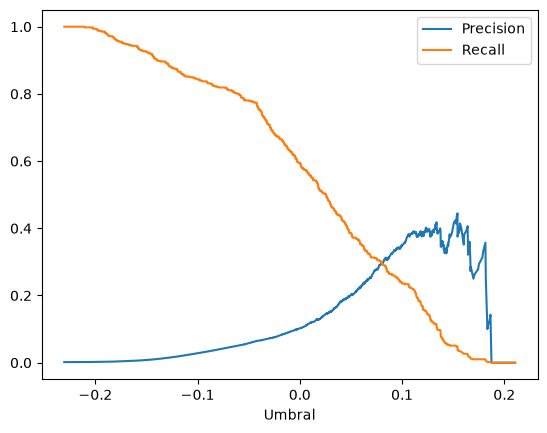

In [38]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

scores = modelo.decision_function(X)

# Invertimos el signo: ahora score alto = más anómalo = más "parecido a fraude"
precision, recall, umbrales = precision_recall_curve(df["Class"], -scores)

plt.plot(umbrales, precision[:-1], label="Precision")
plt.plot(umbrales, recall[:-1], label="Recall")
plt.xlabel("Umbral")
plt.legend()
plt.show()

In [39]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
mejor_idx = np.argmax(f1_scores)

print(f"Mejor umbral: {umbrales[mejor_idx]:.4f}")
print(f"Precision: {precision[mejor_idx]:.2f}, Recall: {recall[mejor_idx]:.2f}")

Mejor umbral: 0.0838
Precision: 0.31, Recall: 0.29


### Resultado del umbral óptimo (sobre la versión con log-transform, contamination=0.01)

| Enfoque | Precision | Recall | F1 |
|---|---|---|---|
| contamination=0.01 (manual) | 0.10 | 0.59 | ~0.17 |
| contamination=0.005 (manual) | 0.16 | 0.47 | ~0.24 |
| **Umbral óptimo por F1 (0.0838)** | **0.31** | **0.29** | **~0.30** |

Calcular el umbral en vez de adivinarlo casi duplicó el F1 respecto al primer intento manual — encontró un punto de balance (31% precision, 29% recall) que ninguno de los valores redondos de `contamination` hubiera dado.

## Versión final consolidada

Con las decisiones ya validadas arriba, esta es la versión limpia y reproducible del pipeline completo:
- **Features:** `V1`-`V28` + `Amount` **sin transformar** (el log-transform no mostró mejora, se descarta).
- **Modelo:** `IsolationForest` con `contamination` por default (`'auto'`) — ya no se usa para decidir el corte final, así que no hace falta fijarlo a mano.
- **Umbral de decisión:** calculado directamente sobre `decision_function()` maximizando F1 contra `Class`, no un `contamination` adivinado.

*(El umbral resultante en esta corrida difiere en valor absoluto del anterior — 0.1624 vs 0.0838 — porque cambiar `contamination` de un valor fijo a `'auto'` desplaza el `offset_` interno de `decision_function()`. La forma de la curva y el F1 óptimo se mantienen prácticamente iguales, lo cual confirma que el resultado es estable.)*

Umbral óptimo: 0.1624
Precision esperada: 0.31
Recall esperado: 0.27
F1 esperado: 0.29


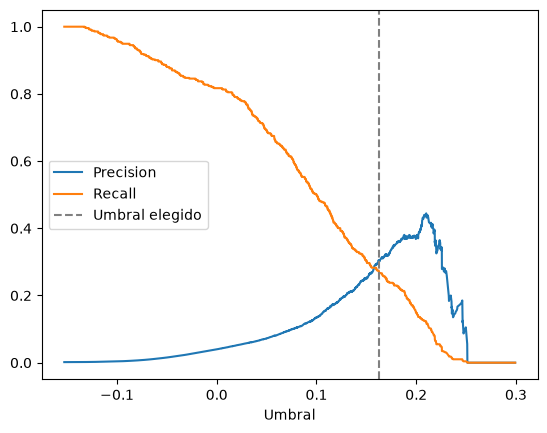

[[284008    307]
 [   359    133]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.30      0.27      0.29       492

    accuracy                           1.00    284807
   macro avg       0.65      0.63      0.64    284807
weighted avg       1.00      1.00      1.00    284807



In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# 1. Seleccionar las columnas que ve el modelo (Amount sin transformar —
#    ya validamos que el log-transform no mejora resultados en este dataset)
features = [f"V{i}" for i in range(1, 29)] + ["Amount"]
X = df[features]

# 2. Crear y entrenar el modelo
#    contamination ya no controla el corte final (usamos umbral calculado más abajo),
#    lo dejamos en 'auto' porque no afecta el entrenamiento en sí, solo predict()
modelo = IsolationForest(random_state=42)
modelo.fit(X)

# 3. Obtener el score continuo de anomalía (no usamos predict() directo)
scores = modelo.decision_function(X)

# 4. Barrer todos los umbrales posibles contra la etiqueta real
#    Invertimos el signo: score alto = más anómalo = más "parecido a fraude"
precision, recall, umbrales = precision_recall_curve(df["Class"], -scores)

# 5. Encontrar el umbral que maximiza F1 (balance entre precision y recall)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
mejor_idx = np.argmax(f1_scores)
UMBRAL_OPTIMO = umbrales[mejor_idx]

print(f"Umbral óptimo: {UMBRAL_OPTIMO:.4f}")
print(f"Precision esperada: {precision[mejor_idx]:.2f}")
print(f"Recall esperado: {recall[mejor_idx]:.2f}")
print(f"F1 esperado: {f1_scores[mejor_idx]:.2f}")

# 6. Visualizar la curva completa (opcional, para el README/análisis)
plt.plot(umbrales, precision[:-1], label="Precision")
plt.plot(umbrales, recall[:-1], label="Recall")
plt.axvline(UMBRAL_OPTIMO, color="gray", linestyle="--", label="Umbral elegido")
plt.xlabel("Umbral")
plt.legend()
plt.show()

# 7. Aplicar el umbral óptimo para obtener las etiquetas finales
#    (ya no usamos modelo.predict(), que depende del contamination del modelo)
etiquetas_finales = (-scores > UMBRAL_OPTIMO).astype(int)

# 8. Validar contra la etiqueta real
print(confusion_matrix(df["Class"], etiquetas_finales))
print(classification_report(df["Class"], etiquetas_finales))

## Conclusión y siguientes pasos

**Modelo final:** `IsolationForest(random_state=42)` sobre `V1`-`V28` + `Amount`, con umbral de decisión ~0.16 (calculado por F1 sobre `decision_function()`), dando **precision ~0.31 / recall ~0.27-0.29**.

**Decisiones documentadas:**
1. Log-transform de `Amount` — probado, sin mejora medible, descartado.
2. `contamination` fijo (0.01 / 0.005) — reemplazado por umbral calculado vía curva precision-recall + F1, con mejor balance resultante.

**Pendiente:**
- Serializar el modelo entrenado con `joblib.dump()`.
- Guardar el umbral óptimo junto con el modelo (metadata), ya que ahora es parte necesaria de la lógica de inferencia.
- Subir el artefacto a S3 para que la Lambda de inferencia lo cargue.

In [ ]:
import joblib

artefacto = {
    "modelo": modelo,
    "umbral": UMBRAL_OPTIMO,
    "features": features,  # V1-V28 + Amount, para no depender del orden a mano
}

joblib.dump(artefacto, "isolation_forest.joblib")

['isolation_forest.joblib']

In [43]:
prueba = joblib.load("isolation_forest.joblib")
print(prueba["umbral"])
print(prueba["features"])
print(type(prueba["modelo"]))

0.1623934265906566
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
<class 'sklearn.ensemble._iforest.IsolationForest'>
